In [1]:
import torch 
import lightning as L
import yaml
import sys, os
import pickle
sys.path.append('../')
# from lightning_scripts.lightning_classifier import LitWordAudioSetModel 
from lightning_scripts.lightning_ssl import LitAudioSSL 
from lightning_scripts.lightning_classifier_matched_speech_in_noise import LitWordAudioSetModel as LitWordAudioSetModelMatched
from lightning_ssl_matched_speech_in_noise import LitAudioSSL as LitAudioSSLMatched
from lightning_scripts.jsinV3DataLoader_precombined_batched import jsinV3_precombined_all_signals
from torchmetrics.classification import Accuracy, BinaryPrecision
import numpy as np 
from tqdm import tqdm
from pathlib import Path
import robustness.audio_functions.audio_transforms as at

In [143]:


# get config and init trained model 
config_path = Path("model_configs/word_speaker_audioset_resnet18_MatchedDataset_shuffle_one_gpu.yaml")
# config_path = Path("model_configs/barlow_word_resnet18_base_Matched_blocked_batches.yaml")
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
# print(config)

config['num_workers'] = 2
config['hparas']['batch_size'] = 192# set to single-gpu size 

# update val set to use entire range 
# config['data']['eval_max'] = -1



checkpoint_dir = Path("model_checkpoints") / f"{config_path.stem}/checkpoints"
ckpt_paths = sorted(checkpoint_dir.glob("*.ckpt"), key=os.path.getctime)
ckpt_path = ckpt_paths[-1] # get latest checkpoint 
print(ckpt_path)

model_checkpoints/word_speaker_audioset_resnet18_MatchedDataset_shuffle_one_gpu/checkpoints/epoch=45-step=110354-best_train.ckpt


In [144]:
config['model']

{'arch_name': 'resnet_multi_task18',
 'arch_params': {'num_classes': {'signal/word_int': 794,
   'signal/speaker_int': 433,
   'noise/labels_int': 517},
  'pretrained': False}}

In [145]:
model = LitWordAudioSetModelMatched.load_from_checkpoint(checkpoint_path=ckpt_path, config=config)
# model = LitAudioSSLMatched.load_from_checkpoint(checkpoint_path=ckpt_path, config=config)
# model = torch.compile(model)
model = model.eval().cuda()


In [146]:
transforms = at.AudioCompose([
                    at.AudioToTensor(),
                    at.DBSPLNormalizeForegroundAndBackground(60),
                    at.UnsqueezeAudio(dim=0) # dim=0 here so batches of audio from dataloader will be (Batch, 1, Time)
                ])

In [147]:
def collate_fn(batch):
    batch = batch[0] # unbox wrapper added by dataloader 
    speech_batch = []
    noise_batch = []
    for (speech, noise) in zip(*batch[:2]):
        speech = transforms(speech, None)[0]
        noise = transforms(noise, None)[0]
        if speech is None:
            speech = torch.zeros(1,40_000)
        if noise is None:
            noise = torch.zeros(1,40_000)
        speech_batch.append(speech)
        noise_batch.append(noise)

    speech_batch = torch.cat(speech_batch).unsqueeze(1)
    noise_batch = torch.cat(noise_batch).unsqueeze(1)
    
    labels = batch[-1] # labels already collated 
    # convert labels to torch tensors 
    if isinstance(labels, dict):
        for task_key, task_labels in labels.items():
            labels[task_key] = torch.from_numpy(task_labels)
    else:
        labels = torch.from_numpy(labels) 
    # convert signal and noise into signal
    return speech_batch, noise_batch, labels 

In [148]:
val_dataset = jsinV3_precombined_all_signals(root="/mnt/ceph/users/jfeather/data/training_datasets_audio/JSIN_all_v3/subsets/",
                                                 train=False,
                                                 transform=None,
                                                 batch_size=config['hparas']['batch_size'],
                                                 eval_max=5)
dataloader = torch.utils.data.DataLoader(
                                        val_dataset,
                                        batch_size=1,
                                        num_workers=config['num_workers'],
                                        shuffle=False,
                                        pin_memory=True,
                                        collate_fn=collate_fn
                                            )

In [149]:
len(val_dataset) * 96 

41760

In [150]:
batch = next(iter(dataloader))

In [151]:
speech, noise, labels = batch

In [152]:
noise.shape

torch.Size([192, 1, 40000])

In [153]:
labels.keys()

dict_keys(['signal/word_int', 'signal/speaker_int', 'noise/labels_binary_via_int'])

In [154]:
model_word_key = [key for key in config['data']['target_keys'] if 'word' in key][0]
model_speaker_key = [key for key in config['data']['target_keys'] if 'speaker' in key][0]
model_noise_key = [key for key in config['data']['target_keys'] if 'noise' in key][0]

In [132]:
model_noise_key



'noise/labels_int'

## EG for SSL model

In [142]:
prec = BinaryPrecision()

word_acc = []
word_top5_acc = []
speaker_acc = []
speaker_top5_acc = []
noise_prec = []
with torch.no_grad():
    for ix, batch in enumerate(tqdm(dataloader)):
        speech, noise, labels = batch
        ### Get word and speaker outs
        _, _, speech_logits = model(speech.cuda())

        word_preds = speech_logits[model_word_key].softmax(-1).cpu()
        speaker_preds = speech_logits[model_speaker_key].softmax(-1).cpu()

        word_acc.append((word_preds.argmax(-1) == labels["signal/word_int"]).numpy().mean()) 
        speaker_acc.append((speaker_preds.argmax(-1) == labels["signal/speaker_int"]).numpy().mean()) 

        # Run top 5 for talker
        word_top5 = torch.isin(torch.topk(word_preds, k=5, dim=-1).indices, labels["signal/word_int"]).any(-1).numpy().mean()
        word_top5_acc.append(word_top5)
        # Run top 5 for talker
        speaker_top5 = torch.isin(torch.topk(speaker_preds, k=5, dim=-1).indices, labels["signal/speaker_int"]).any(-1).numpy().mean()
        speaker_top5_acc.append(speaker_top5)
        ### Get noise label outs 
        _, _, noise_logits = model(noise.cuda())
        noise_logits = noise_logits[model_noise_key].cpu()
        noise_prec.append(prec(noise_logits, labels['noise/labels_binary_via_int']).item())
        if ix == 9:
            break

word_mean = np.mean(word_acc)
speaker_mean = np.mean(speaker_acc)
noise_mean = np.mean(noise_prec)

print(f"Word top-1: {word_mean:.3f}")
print(f"Word top-5: {np.mean(word_top5_acc):.3f}")
print(f"Speaker top-1: {speaker_mean:.3f}")
print(f"Speaker top-5: {np.mean(speaker_top5_acc):.3f}")
print(f"Noise mAP: {noise_mean:.3f}")

  2%|▏         | 9/435 [00:05<04:09,  1.71it/s]

Word top-1: 0.018
Word top-5: 0.987
Speaker top-1: 0.161
Speaker top-5: 0.983
Noise mean: 0.000


In [141]:
prec(noise_logits.sigmoid(), labels['noise/labels_binary_via_int']).shape

torch.Size([192])

In [92]:
torch.isin(torch.topk(speech_logits[model_word_key].softmax(-1), k=5, dim=-1).indices.cpu(), labels["signal/word_int"]).any(-1)

torch.Size([192])

In [80]:
%matplotlib inline
import matplotlib.pyplot as plt 

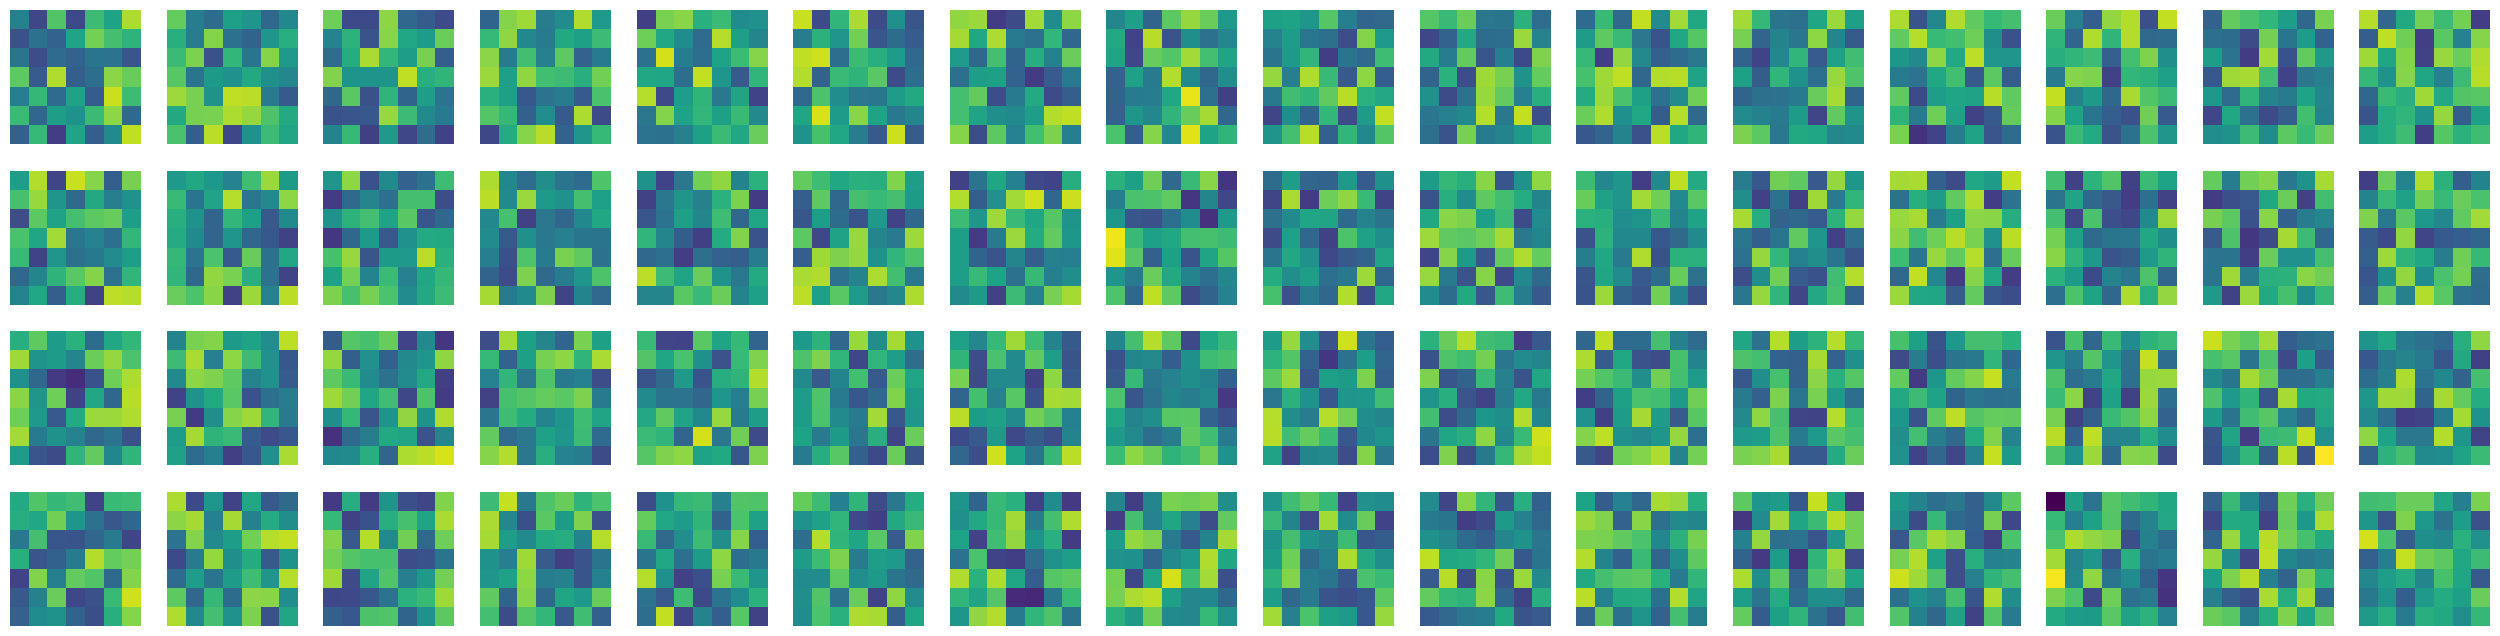

In [82]:
### Plot first layer weights 
conv1_kernels = model.model.model.f.conv1.weight.squeeze().cpu().detach()

aspect = 2
fig, axs = plt.subplots(4,16, figsize=(16*aspect, 4*aspect))
axs = axs.ravel()
for ix, kernel in enumerate(conv1_kernels):
    axs[ix].imshow(kernel, aspect='auto', vmin=conv1_kernels.min(), vmax=conv1_kernels.max(), interpolation="none")
    axs[ix].axis('off')


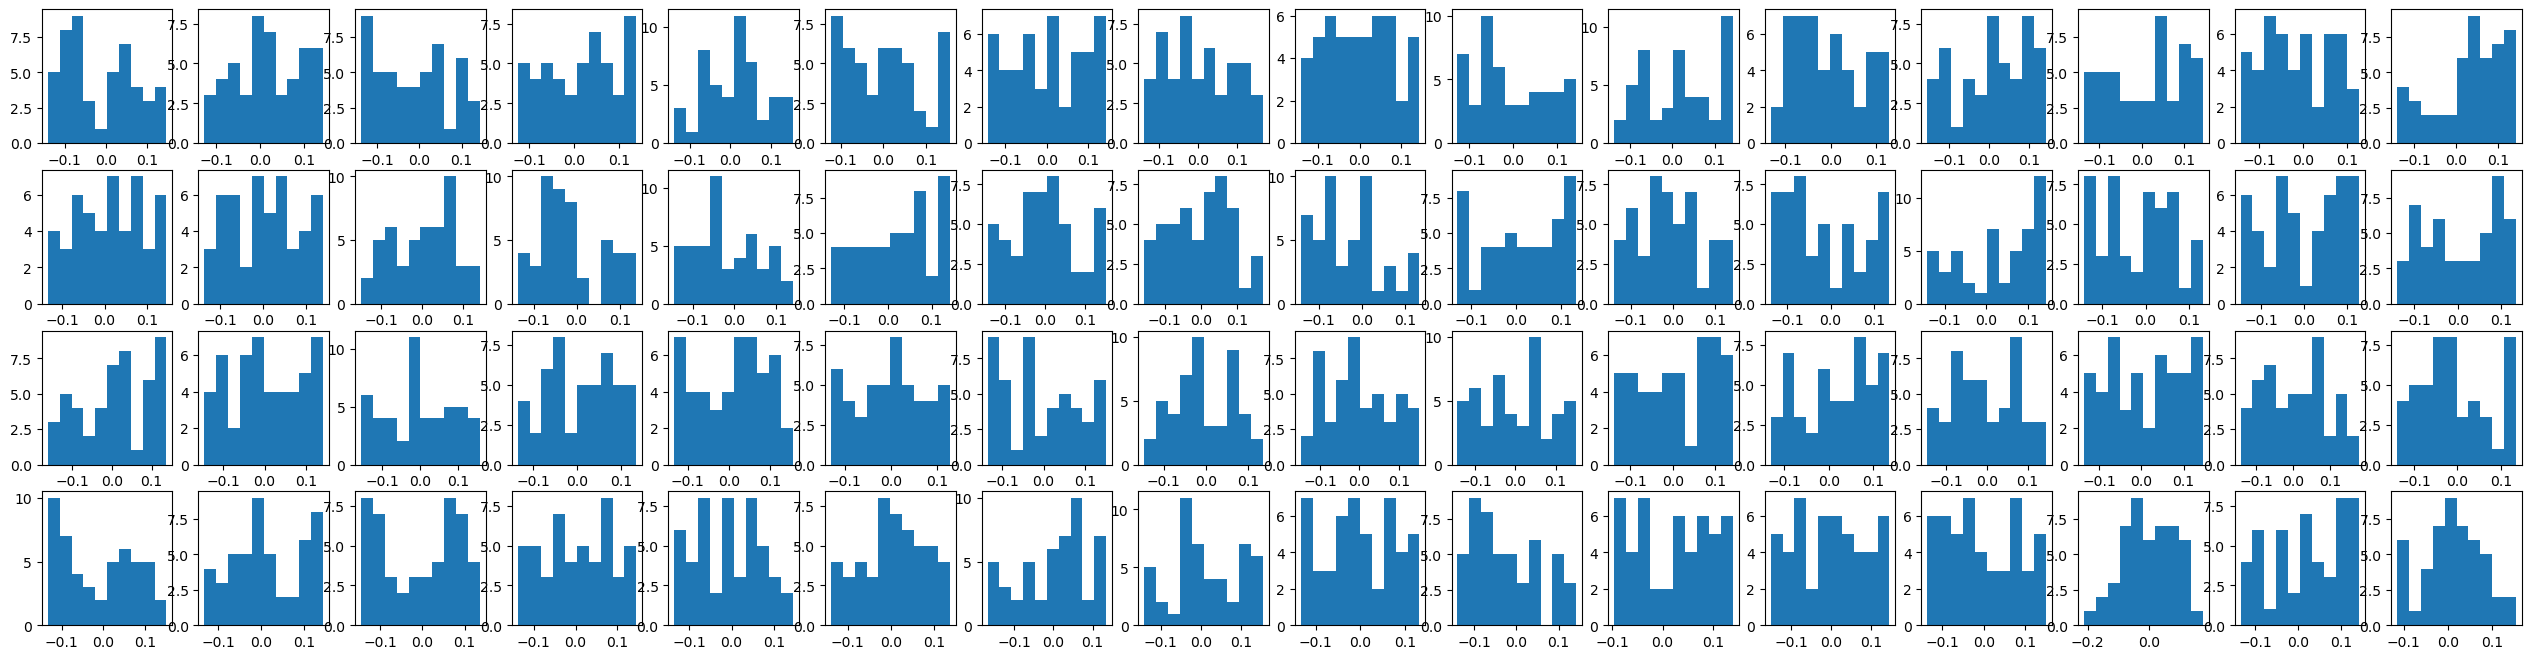

In [85]:
aspect = 2
fig, axs = plt.subplots(4,16, figsize=(16*aspect, 4*aspect))
axs = axs.ravel()
for ix, kernel in enumerate(conv1_kernels):
    axs[ix].hist(kernel.ravel())
    # axs[ix].axis('off')


## EG for supervised model

In [157]:
prec = BinaryPrecision()

word_acc = []
word_top5_acc = []
speaker_acc = []
speaker_top5_acc = []
noise_prec = []

with torch.no_grad():
    for ix, batch in enumerate(tqdm(dataloader)):
        speech, noise, labels = batch
        ### Get word and speaker outs
        speech_logits = model(speech.cuda())

        word_preds = speech_logits[model_word_key].softmax(-1).cpu()
        speaker_preds = speech_logits[model_speaker_key].softmax(-1).cpu()

        word_acc.append((word_preds.argmax(-1) == labels["signal/word_int"]).numpy().mean()) 
        speaker_acc.append((speaker_preds.argmax(-1) == labels["signal/speaker_int"]).numpy().mean()) 

        # Run top 5 for talker
        word_top5 = torch.isin(torch.topk(word_preds, k=5, dim=-1).indices, labels["signal/word_int"]).any(-1).numpy().mean()
        word_top5_acc.append(word_top5)
        # Run top 5 for talker
        speaker_top5 = torch.isin(torch.topk(speaker_preds, k=5, dim=-1).indices, labels["signal/speaker_int"]).any(-1).numpy().mean()
        speaker_top5_acc.append(speaker_top5)

        ### Get noise label outs 
        noise_logits = model(noise.cuda())[model_noise_key].cpu()
        noise_prec.append(prec(noise_logits, labels['noise/labels_binary_via_int']).item())
        if ix == 9:
            break


word_mean = np.mean(word_acc)
speaker_mean = np.mean(speaker_acc)
noise_mean = np.mean(noise_prec)

print(f"Word top-1: {word_mean:.3f}")
print(f"Word top-5: {np.mean(word_top5_acc):.3f}")
print(f"Speaker top-1: {speaker_mean:.3f}")
print(f"Speaker top-5: {np.mean(speaker_top5_acc):.3f}")
print(f"Noise mAP: {noise_mean:.3f}")

  2%|▏         | 9/435 [00:05<04:15,  1.67it/s]

Word top-1: 0.801
Word top-5: 0.985
Speaker top-1: 0.649
Speaker top-5: 0.976
Noise mAP: 0.558
